In [108]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [109]:
path = r"..\Data\cleaned_customer_with_rfm.csv"
df = pd.read_csv(path)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [110]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,recency,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,302,309,5303.48,4,1,1,411,At Risk


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 401604 entries, 0 to 401603
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       401604 non-null  str           
 1   StockCode       401604 non-null  str           
 2   Description     401604 non-null  str           
 3   Quantity        401604 non-null  int64         
 4   InvoiceDate     401604 non-null  datetime64[us]
 5   UnitPrice       401604 non-null  float64       
 6   CustomerID      401604 non-null  float64       
 7   Country         401604 non-null  str           
 8   TotalPrice      401604 non-null  float64       
 9   Year            401604 non-null  int64         
 10  Month           401604 non-null  int64         
 11  Day             401604 non-null  int64         
 12  recency         401604 non-null  int64         
 13  frequency       401604 non-null  int64         
 14  monetary_value  401604 non-null  float64       

In [112]:
max_date = df['InvoiceDate'].max()

df['LastPurchaseDate'] = df.groupby('CustomerID')['InvoiceDate'].transform('max')

df['DaysSinceLastPurchase'] = (max_date - df['LastPurchaseDate']).dt.days

df['Churn'] = (df['DaysSinceLastPurchase'] > 90).astype(int)

In [113]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,...,frequency,monetary_value,r_quartile,f_quartile,m_quartile,RFMScore,Segment,LastPurchaseDate,DaysSinceLastPurchase,Churn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,...,309,5303.48,4,1,1,411,At Risk,2011-02-10 14:38:00,301,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,309,5303.48,4,1,1,411,At Risk,2011-02-10 14:38:00,301,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,...,309,5303.48,4,1,1,411,At Risk,2011-02-10 14:38:00,301,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,309,5303.48,4,1,1,411,At Risk,2011-02-10 14:38:00,301,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,309,5303.48,4,1,1,411,At Risk,2011-02-10 14:38:00,301,1


In [114]:
print(f"Churnd Shape:- {df[df['Churn'] == 1].shape}")
print(f"Not Churnd Shape:- {df[df['Churn'] == 0].shape}")

Churnd Shape:- (47497, 23)
Not Churnd Shape:- (354107, 23)


In [115]:
# Customer per country churned and not chured

customer_data = df[['CustomerID', 'Country', 'Churn']].drop_duplicates()
churn_country = customer_data.groupby(['Country', 'Churn'])['CustomerID'].nunique().reset_index()
churn_pivot = churn_country.pivot(index='Country', columns='Churn', values='CustomerID').fillna(0)

# Rename columns for clarity
churn_pivot.columns = ['Not_Churned', 'Churned']

churn_pivot = churn_pivot.sort_values(by='Churned', ascending=False)

churn_pivot

,Not_Churned,Churned
Country,,
United Kingdom,2641.0,1309.0
Germany,70.0,25.0
France,63.0,24.0
Spain,22.0,9.0
Switzerland,12.0,9.0
Belgium,18.0,7.0
Portugal,13.0,6.0
Italy,10.0,5.0
Austria,6.0,5.0


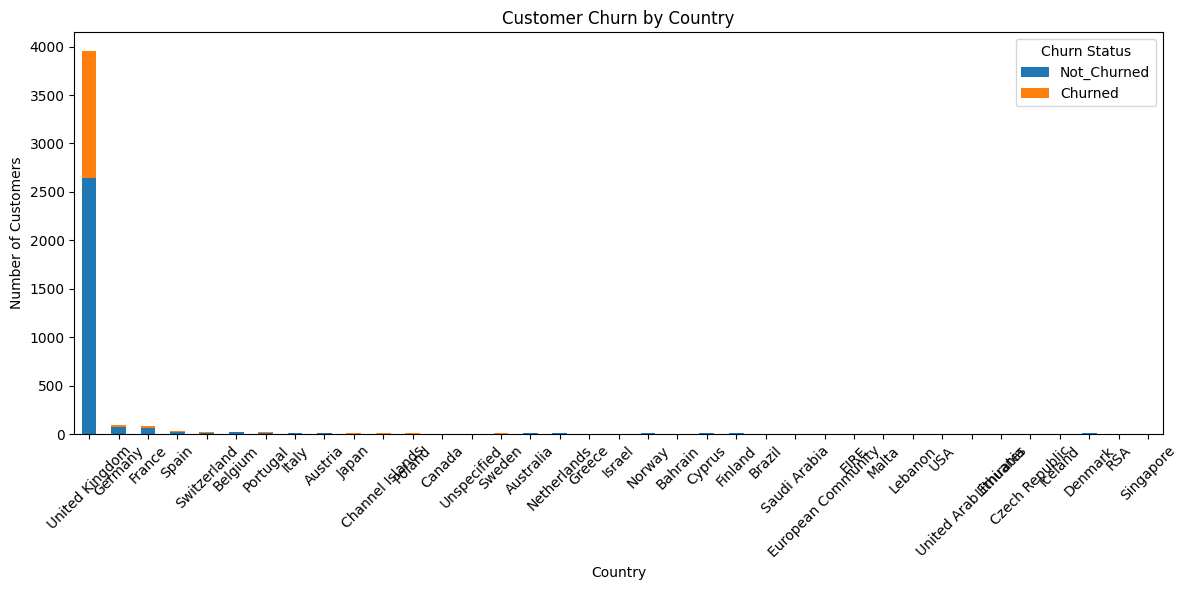

In [116]:
churn_pivot.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Customer Churn by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Churn Status')
plt.tight_layout()
plt.show()

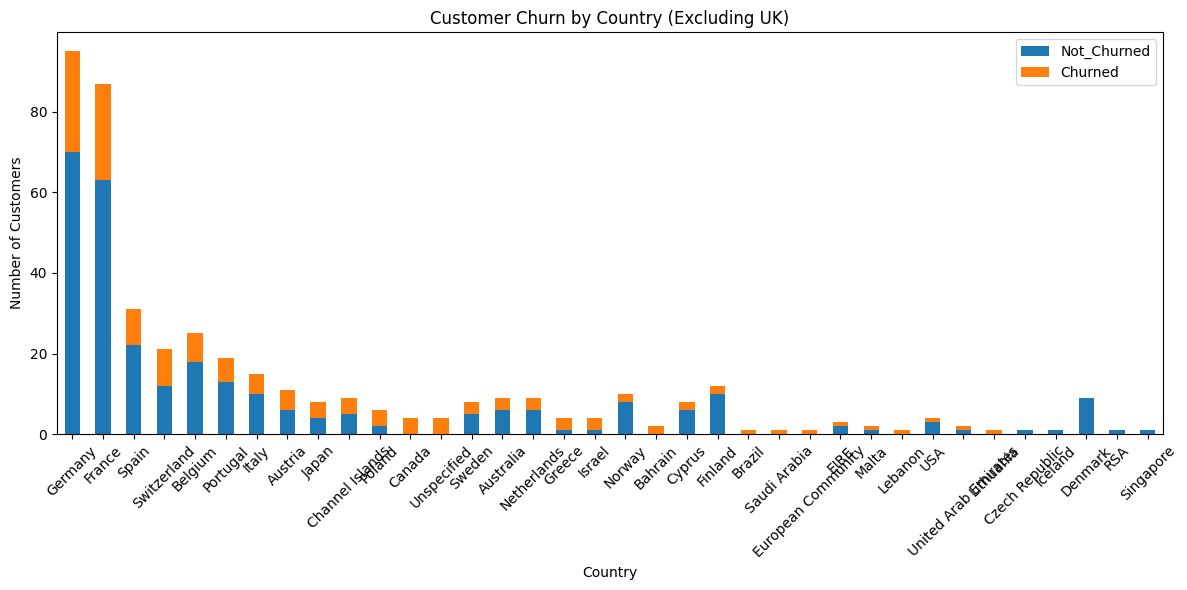

In [117]:
filtered_data = churn_pivot.drop('United Kingdom')

filtered_data.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Customer Churn by Country (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [118]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice', 'Year', 'Month',
       'Day', 'recency', 'frequency', 'monetary_value', 'r_quartile',
       'f_quartile', 'm_quartile', 'RFMScore', 'Segment', 'LastPurchaseDate',
       'DaysSinceLastPurchase', 'Churn'],
      dtype='str')

In [119]:
df['UK_Flag'] = (df['Country'] == 'United Kingdom').astype(int)

In [120]:
cols = ['UK_Flag', 'TotalPrice', 'Year', 'Month','Day', 'recency', 'frequency', 'monetary_value', 'Churn']

In [121]:
df_new = df[cols]

In [122]:
df_new.head()

,UK_Flag,TotalPrice,Year,Month,Day,recency,frequency,monetary_value,Churn
0,1,15.30,2010,12,1,302,309,5303.48,1
1,1,20.34,2010,12,1,302,309,5303.48,1
2,1,22.00,2010,12,1,302,309,5303.48,1
3,1,20.34,2010,12,1,302,309,5303.48,1
4,1,20.34,2010,12,1,302,309,5303.48,1


In [123]:
df_reduced = df_new.drop(columns=['Year', 'Month', 'Day', 'Churn'])

In [124]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_reduced)

In [125]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Churn'] = df['Churn'].values

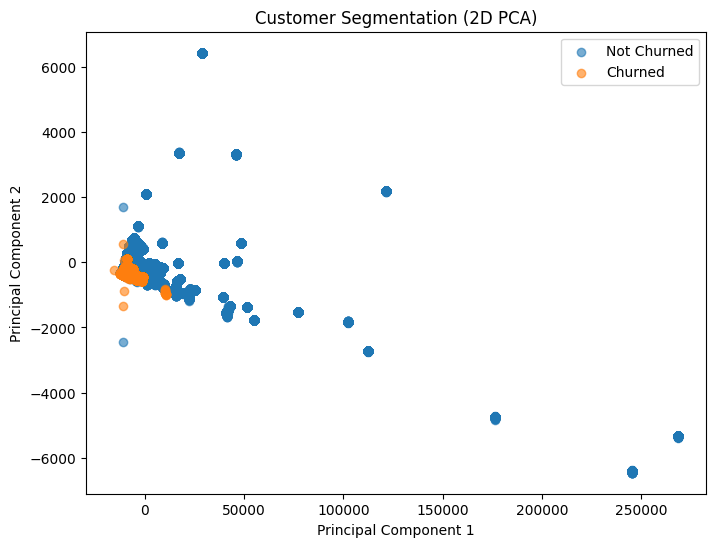

In [126]:
plt.figure(figsize=(8,6))

# churn = 0
plt.scatter(
    pca_df[pca_df['Churn'] == 0]['PC1'],
    pca_df[pca_df['Churn'] == 0]['PC2'],
    label='Not Churned',
    alpha=0.6
)

# churn = 1
plt.scatter(
    pca_df[pca_df['Churn'] == 1]['PC1'],
    pca_df[pca_df['Churn'] == 1]['PC2'],
    label='Churned',
    alpha=0.6
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segmentation (2D PCA)')
plt.legend()
plt.show()

In [127]:
X = df_new.drop(columns=['Churn', 'Year', 'Month', 'Day'])
y = df_new['Churn']

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [131]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]  # probability of churn

In [132]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9996513987624656
